# 01 — Portfolio surveillance walkthrough

A compact, executable review of the synthetic wholesale portfolio. The notebook uses the same reusable functions as `main.py`; no figures or conclusions are hard-coded.

In [1]:
from pathlib import Path
import os
import sys
import yaml
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.data_ingestion import fetch_macro_data, generate_panel
from src.eda_portfolio import (
    latest_snapshot, performance_trends, quarterly_default_rate,
    sector_breakdown, summarise_portfolio, watchlist,
)
from src.concentration_risk import concentration_by_dimension, top_n_obligors

with open('config.yaml', encoding='utf-8') as handle:
    config = yaml.safe_load(handle)
macro = fetch_macro_data(config)
panel = generate_panel(1200, seed=config['project']['seed'], macro_df=macro)
current = latest_snapshot(panel)
f'{len(panel):,} rows | {current.obligor_id.nunique():,} current obligors | £{current.ead.sum()/1e9:.2f}bn EAD'

'24,576 rows | 1,200 current obligors | £6.21bn EAD'

## Current portfolio and concentration

In [2]:
summary = summarise_portfolio(panel)
sectors = sector_breakdown(panel)
display(summary)
display(sectors.head())

,rating,count,total_ead,wa_pd,wa_lgd,total_el,el_pct_ead,ead_share_pct
0,AAA,27,1.323765e+08,0.000240,0.362013,1.145256e+04,0.000087,2.130613
1,AA,90,4.866572e+08,0.000196,0.370072,3.522572e+04,0.000072,7.832797
2,A,212,1.214887e+09,0.000433,0.355500,1.866070e+05,0.000154,19.553734
3,BBB,278,1.600386e+09,0.001060,0.381340,6.477617e+05,0.000405,25.758369
4,BB,239,1.340390e+09,0.005637,0.344194,2.601903e+06,0.001941,21.573713
5,B,161,8.713428e+08,0.024256,0.353830,7.478614e+06,0.008583,14.024350
6,CCC,44,2.966925e+08,0.205989,0.365730,2.246081e+07,0.075704,4.775296
7,D,149,2.703387e+08,1.000000,0.375231,1.014395e+08,0.375231,4.351129


,sector,n_obligors,total_ead,total_el,defaulted_ead,el_rate,ead_share_pct,defaulted_ead_pct
0,Manufacturing,169,8.912300e+08,3.443460e+07,6.463263e+07,0.038637,14.344436,7.252071
1,Energy,168,8.315982e+08,1.056828e+07,2.211623e+07,0.012708,13.384657,2.659485
2,Financial Services,150,8.110881e+08,1.870801e+07,2.160751e+07,0.023065,13.054545,2.664015
3,Real Estate,140,6.924957e+08,1.350245e+07,2.942351e+07,0.019498,11.145788,4.248908
4,Healthcare,106,5.999510e+08,1.108084e+07,2.391148e+07,0.018470,9.656272,3.985571


In [3]:
sector_concentration = concentration_by_dimension(current, 'sector')
top_names = top_n_obligors(current, 20)
controls = pd.Series({
    'largest_sector_pct': sector_concentration.share_pct.iloc[0],
    'sector_hhi': sector_concentration.hhi_contribution.sum(),
    'largest_name_pct': top_names.share_pct.iloc[0],
    'top_20_pct': top_names.share_pct.sum(),
})
controls.to_frame('result')

,result
largest_sector_pct,14.344436
sector_hhi,0.107044
largest_name_pct,1.438506
top_20_pct,8.536531


## Performance and emerging risk

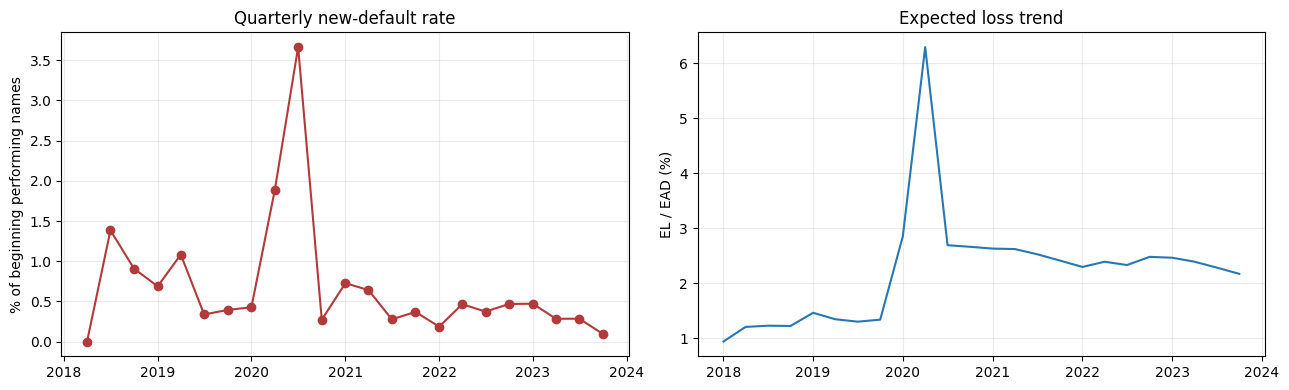

In [4]:
defaults = quarterly_default_rate(panel)
trends = performance_trends(panel)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(defaults.snapshot_date, defaults.default_rate_pct, color='#B33A3A', marker='o')
axes[0].set(title='Quarterly new-default rate', ylabel='% of beginning performing names')
axes[1].plot(trends.snapshot_date, trends.el_pct_ead * 100, color='#2678B2')
axes[1].set(title='Expected loss trend', ylabel='EL / EAD (%)')
for axis in axes:
    axis.grid(alpha=.25)
fig.tight_layout();

In [5]:
watch = watchlist(panel)
pd.Series({
    'watchlist_names': len(watch),
    'watchlist_ead_pct': watch.ead.sum() / current.ead.sum() * 100,
    'latest_quarter_default_pct': defaults.default_rate_pct.iloc[-1],
    'new_defaults_all_periods': int(panel.is_new_default.sum()),
}).to_frame('result')

,result
watchlist_names,184.000000
watchlist_ead_pct,17.474787
latest_quarter_default_pct,0.095057
new_defaults_all_periods,149.000000


## Interpretation

The watchlist is a transparent screening rule, not a model. Names require credit-officer review for refinancing, covenant, liquidity and collateral context. Default-rate denominators exclude already-defaulted obligors, and the report preserves both event counts and exposure-weighted portfolio measures.